In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for all charts
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load cleaned datasets
layoffs = pd.read_csv('../data/cleaned/layoffs_clean.csv')
placement = pd.read_csv('../data/cleaned/placement_clean.csv')
hr = pd.read_csv('../data/cleaned/hr_clean.csv')

print("✅ All cleaned datasets loaded!")
print(f"Layoffs: {layoffs.shape}")
print(f"Placement: {placement.shape}")
print(f"HR: {hr.shape}")

✅ All cleaned datasets loaded!
Layoffs: (4428, 11)
Placement: (100000, 18)
HR: (1470, 35)


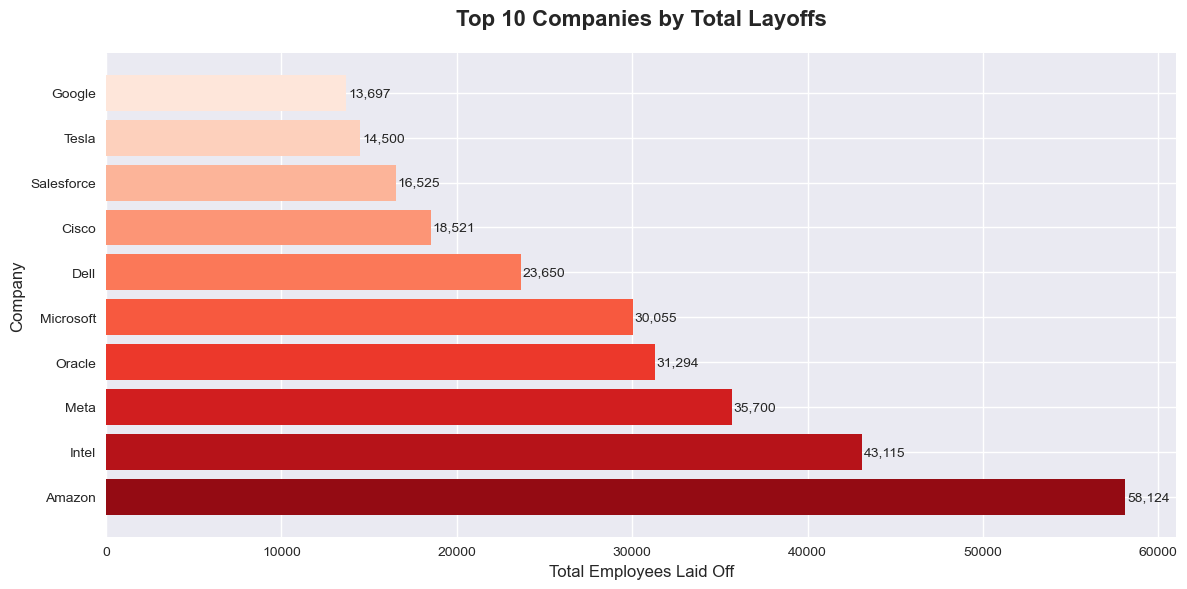

✅ Chart 1 saved!


In [2]:
plt.figure(figsize=(12, 6))

top_companies = layoffs.groupby('company')['total_laid_off'].sum()
top_companies = top_companies.sort_values(ascending=False).head(10)

bars = plt.barh(top_companies.index, 
                top_companies.values, 
                color=sns.color_palette("Reds_r", 10))

plt.title('Top 10 Companies by Total Layoffs', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Employees Laid Off', fontsize=12)
plt.ylabel('Company', fontsize=12)

# Add value labels on bars
for i, v in enumerate(top_companies.values):
    plt.text(v + 100, i, f'{int(v):,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/charts/chart1_top_companies.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

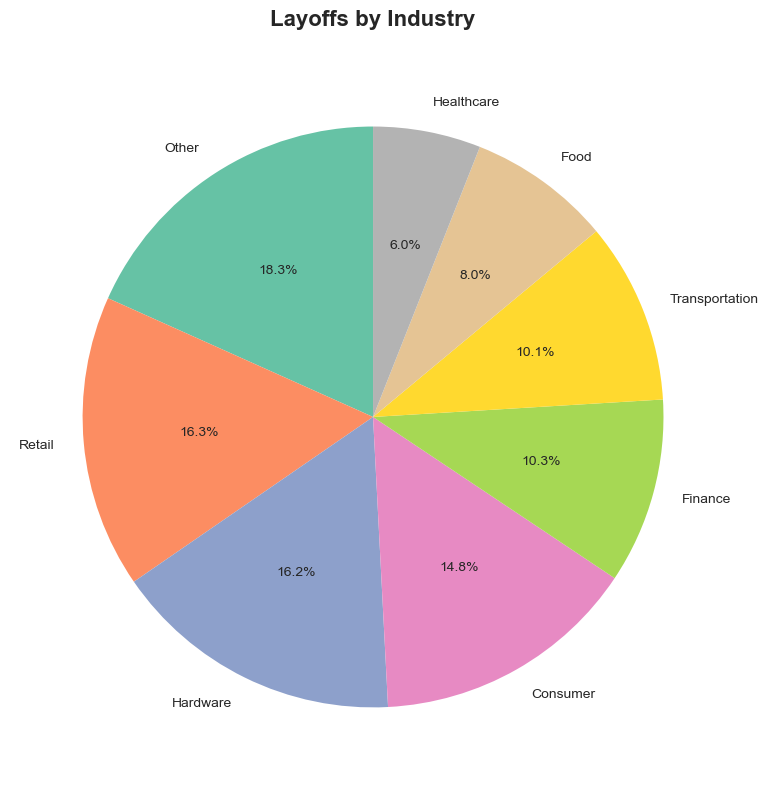

✅ Chart 2 saved!


In [3]:
plt.figure(figsize=(10, 8))

industry_layoffs = layoffs.groupby('industry')['total_laid_off'].sum()
industry_layoffs = industry_layoffs.sort_values(ascending=False).head(8)

colors = sns.color_palette("Set2", len(industry_layoffs))
wedges, texts, autotexts = plt.pie(
    industry_layoffs.values,
    labels=industry_layoffs.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)

plt.title('Layoffs by Industry', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/charts/chart2_industry_layoffs.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

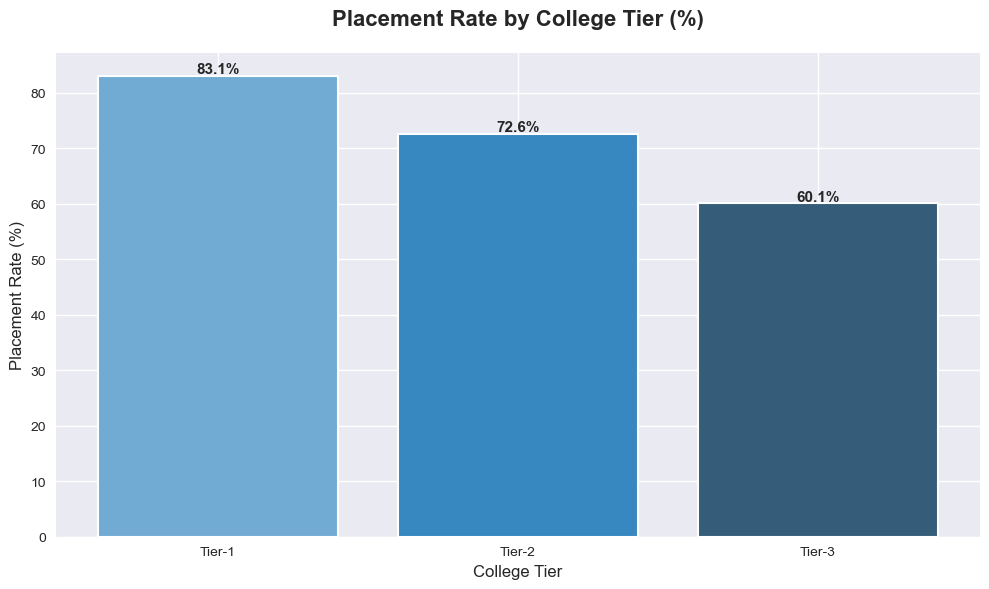

✅ Chart 3 saved!


In [4]:
plt.figure(figsize=(10, 6))

tier_placement = placement.groupby('college_tier')['placement_status'].apply(
    lambda x: (x == 1).sum() / len(x) * 100
).reset_index()
tier_placement.columns = ['college_tier', 'placement_rate']
tier_placement = tier_placement.sort_values('placement_rate', ascending=False)

bars = plt.bar(tier_placement['college_tier'], 
               tier_placement['placement_rate'],
               color=sns.color_palette("Blues_d", len(tier_placement)),
               edgecolor='white', linewidth=1.5)

plt.title('Placement Rate by College Tier (%)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('College Tier', fontsize=12)
plt.ylabel('Placement Rate (%)', fontsize=12)

for bar, rate in zip(bars, tier_placement['placement_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/charts/chart3_placement_by_tier.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

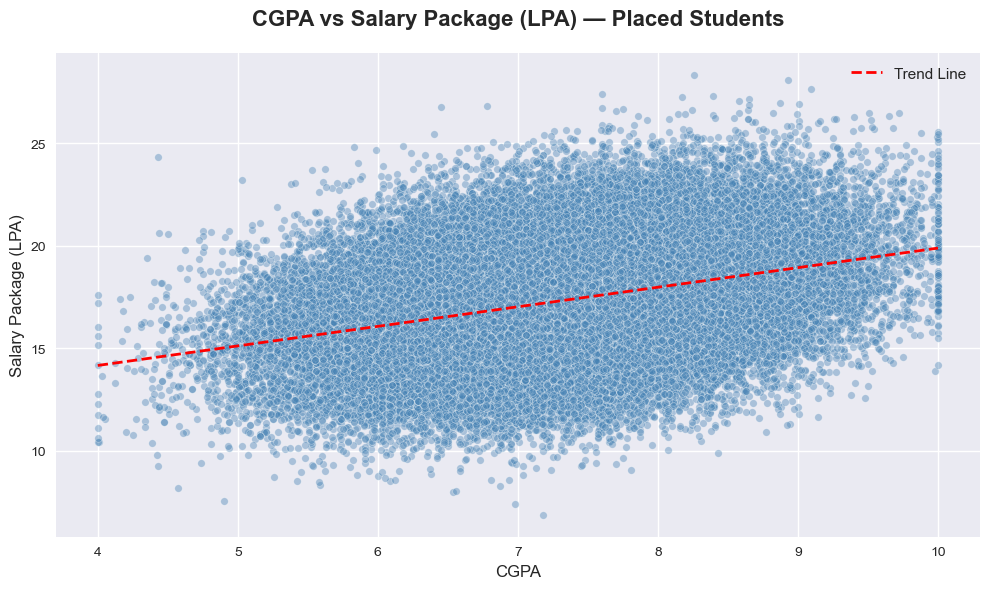

✅ Chart 4 saved!


In [5]:
plt.figure(figsize=(10, 6))

# Filter only placed students
placed = placement[placement['placement_status'] == 1]

plt.scatter(placed['cgpa'], 
            placed['salary_package_lpa'],
            alpha=0.4, 
            color='steelblue',
            edgecolors='white',
            linewidth=0.5,
            s=30)

# Add trend line
z = np.polyfit(placed['cgpa'], placed['salary_package_lpa'], 1)
p = np.poly1d(z)
plt.plot(sorted(placed['cgpa']), 
         p(sorted(placed['cgpa'])), 
         "r--", linewidth=2, label='Trend Line')

plt.title('CGPA vs Salary Package (LPA) — Placed Students', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Salary Package (LPA)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/charts/chart4_cgpa_vs_salary.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

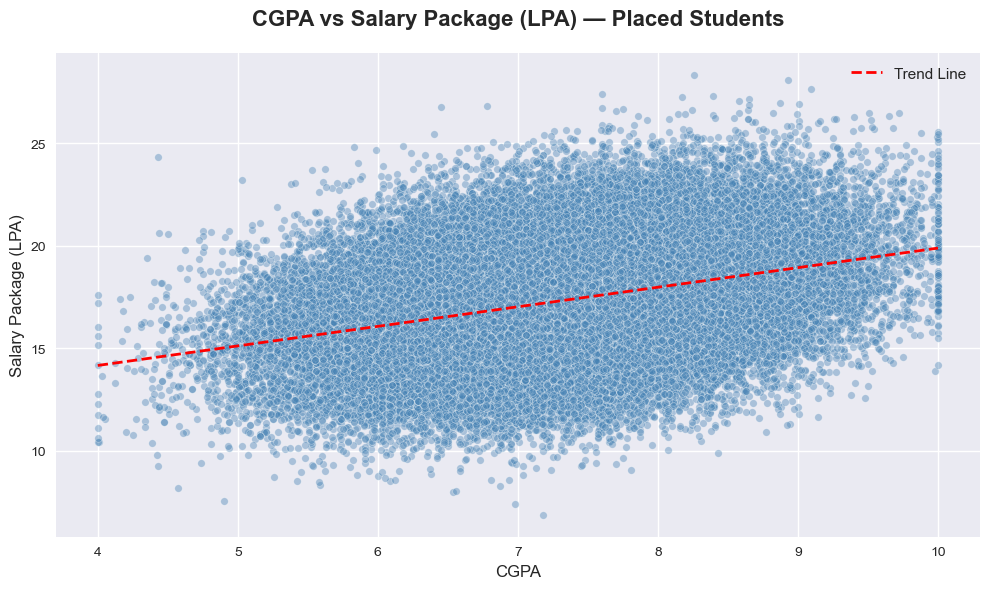

✅ Chart 4 saved!


In [6]:
plt.figure(figsize=(10, 6))

# Filter only placed students
placed = placement[placement['placement_status'] == 1]

plt.scatter(placed['cgpa'], 
            placed['salary_package_lpa'],
            alpha=0.4, 
            color='steelblue',
            edgecolors='white',
            linewidth=0.5,
            s=30)

# Add trend line
z = np.polyfit(placed['cgpa'], placed['salary_package_lpa'], 1)
p = np.poly1d(z)
plt.plot(sorted(placed['cgpa']), 
         p(sorted(placed['cgpa'])), 
         "r--", linewidth=2, label='Trend Line')

plt.title('CGPA vs Salary Package (LPA) — Placed Students', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Salary Package (LPA)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/charts/chart4_cgpa_vs_salary.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

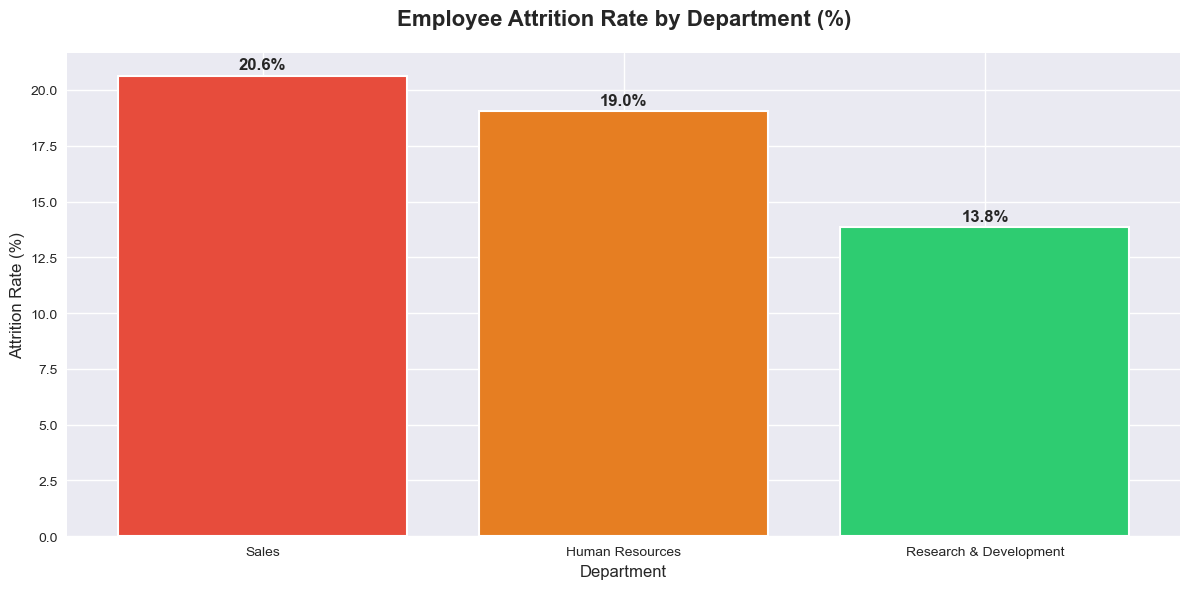

✅ Chart 5 saved!


In [7]:
plt.figure(figsize=(12, 6))

dept_attrition = hr.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
dept_attrition.columns = ['Department', 'Attrition_Rate']
dept_attrition = dept_attrition.sort_values('Attrition_Rate', ascending=False)

bars = plt.bar(dept_attrition['Department'],
               dept_attrition['Attrition_Rate'],
               color=['#e74c3c', '#e67e22', '#2ecc71'],
               edgecolor='white', linewidth=1.5)

plt.title('Employee Attrition Rate by Department (%)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)

for bar, rate in zip(bars, dept_attrition['Attrition_Rate']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/charts/chart5_attrition_by_dept.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

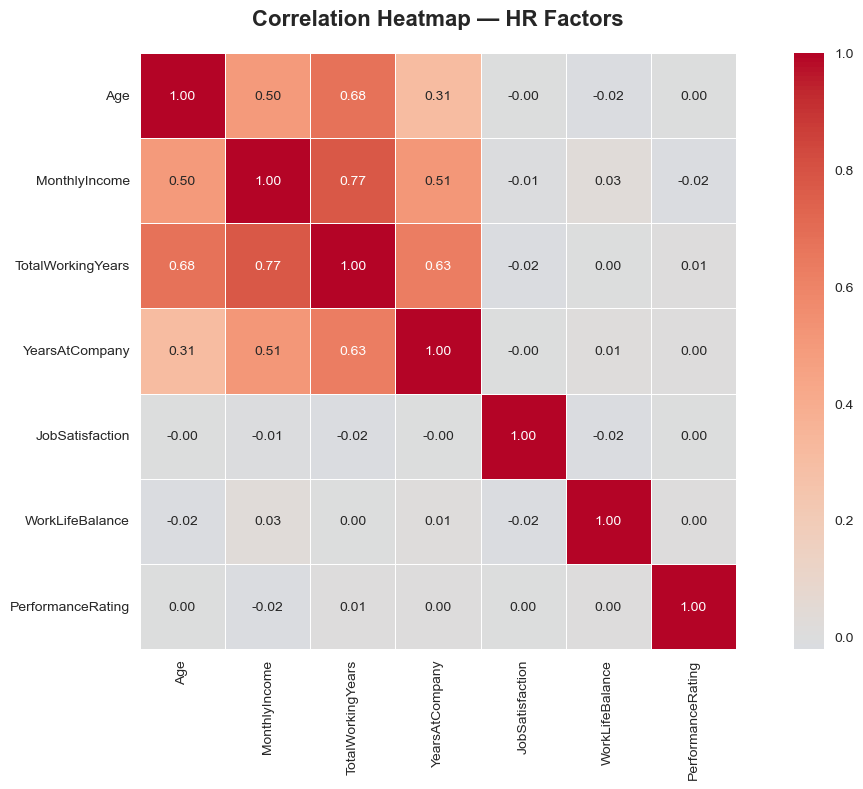

✅ Chart 6 saved!


In [8]:
plt.figure(figsize=(12, 8))

# Select important numeric columns
hr_numeric = hr[['Age', 'MonthlyIncome', 'TotalWorkingYears',
                  'YearsAtCompany', 'JobSatisfaction', 
                  'WorkLifeBalance', 'PerformanceRating']].copy()

correlation = hr_numeric.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap — HR Factors',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../data/charts/chart6_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

In [9]:
print("=" * 60)
print("📊 KEY BUSINESS INSIGHTS")
print("=" * 60)

# Insight 1
top_company = layoffs.groupby('company')['total_laid_off'].sum().idxmax()
top_count = int(layoffs.groupby('company')['total_laid_off'].sum().max())
print(f"\n🔴 Insight 1 — Layoffs:")
print(f"   {top_company} had highest layoffs: {top_count:,} employees")

# Insight 2
top_industry = layoffs.groupby('industry')['total_laid_off'].sum().idxmax()
print(f"\n🔴 Insight 2 — Industry:")
print(f"   {top_industry} industry was hit hardest by layoffs")

# Insight 3
overall_placement = (placement['placement_status'] == 1).sum() / len(placement) * 100
print(f"\n🟡 Insight 3 — Placement:")
print(f"   Overall placement rate: {overall_placement:.1f}%")

# Insight 4
avg_salary = placement[placement['placement_status']==1]['salary_package_lpa'].mean()
print(f"\n🟡 Insight 4 — Salary:")
print(f"   Average salary of placed students: {avg_salary:.2f} LPA")

# Insight 5
total_attrition = (hr['Attrition'] == 'Yes').sum() / len(hr) * 100
print(f"\n🟢 Insight 5 — HR Attrition:")
print(f"   Overall employee attrition rate: {total_attrition:.1f}%")

print("\n" + "=" * 60)
print("✅ EDA Complete! 6 Charts + 5 Key Insights Generated!")
print("=" * 60)

📊 KEY BUSINESS INSIGHTS

🔴 Insight 1 — Layoffs:
   Amazon had highest layoffs: 58,124 employees

🔴 Insight 2 — Industry:
   Other industry was hit hardest by layoffs

🟡 Insight 3 — Placement:
   Overall placement rate: 68.5%

🟡 Insight 4 — Salary:
   Average salary of placed students: 17.31 LPA

🟢 Insight 5 — HR Attrition:
   Overall employee attrition rate: 16.1%

✅ EDA Complete! 6 Charts + 5 Key Insights Generated!
